In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path


In [10]:
# Carpeta donde está guardado el modelo
MODELS_DIR = Path("../models")
MODEL_PATH = MODELS_DIR / "modelo_residuos_rpi.keras" # modelo generado después de ejecutar el script de entrenamiento

# Ruta del dataset original (la misma que usaste al entrenar)
DATASET_PATH = Path("../data/raw/waste_classification/images/dataset_final") # este directorio se crea despues de ejecutar el script de entrenamiento


In [11]:
print("Cargando modelo...")
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Modelo cargado correctamente")


Cargando modelo...
✅ Modelo cargado correctamente


In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    str(DATASET_PATH),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_gen.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

NUM_CLASSES = len(index_to_class)

print(f"✅ Clases detectadas: {NUM_CLASSES}")
print(index_to_class)


Found 6147 images belonging to 4 classes.
✅ Clases detectadas: 4
{0: 'crushed metal', 1: 'crushed plastic', 2: 'metal', 3: 'plastic'}


In [13]:
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array


In [14]:
def predict_image(img_path):
    img_array = preprocess_image(img_path)
    
    predictions = model.predict(img_array)
    
    predicted_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    
    predicted_class = index_to_class[predicted_index]
    
    return predicted_class, confidence


In [15]:
img_path = "../data/raw/test/images/lata_de_arizona.jpeg"  # <-- CAMBIA POR TU IMAGEN

predicted_class, confidence = predict_image(img_path)

print("🔎 Clase predicha:", predicted_class)
print("📊 Confianza:", round(float(confidence) * 100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
🔎 Clase predicha: metal
📊 Confianza: 99.21 %


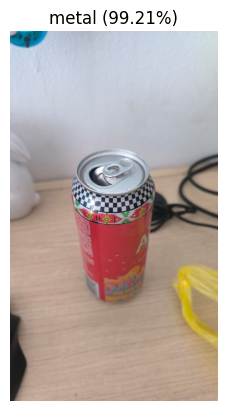

In [16]:
img = image.load_img(img_path)

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()
